# Equipo 3 - Perspectiva Estelar
### Noah Ancalao, Cristóbal Manríquez y Fernando Rojas

## 1. Introducción y contexto.

**Enfoque:**
Nuestro análisis se enfoca en las variables propias de la estrella anfitriona.

**Objetivo:**
El objetivo de nuestro análisis es encontrar una relación entre las características de la estrella anfitriona y la
habitabilidad de los planetas. Luego encontrar los mejores candidatos a planetas habitables.

**Variables Relevantes:**
Tras un análisis estadístico superficial, consideramos relevantes las variables de *Radio Estelar*, *Masa Estelar*, *Edad de la Estrella*, *Metalicidad*, *Temperatura* y *Luminosidad*. Además, se contrastarán con la variable de *Habitabilidad del Planeta*, dada por el conjunto de datos.

## 2. Inspección y preparación de los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# se leen los datos, seleccionando columnas sugeridas para caracterización estelar
data = pd.read_csv("hwc.csv", usecols=["P_NAME", "P_HABITABLE", "S_TYPE", "S_TYPE_TEMP", "S_TEMPERATURE", "S_MASS", "S_RADIUS", "S_LOG_LUM",
"S_LOG_G", "S_AGE", "S_METALLICITY", "S_DISTANCE", "S_HZ_OPT_MIN", "S_HZ_OPT_MAX", "S_HZ_CON_MIN",
"S_HZ_CON_MAX", "S_TIDAL_LOCK", "S_SNOW_LINE", "S_ABIO_ZONE", "P_ESI"])
data

,P_NAME,S_TYPE,S_DISTANCE,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM,S_LOG_G,S_TYPE_TEMP,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABITABLE,P_ESI
0,OGLE-2016-BLG-1227L b,NaN,NaN,NaN,0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.214133,0,NaN
1,Kepler-276 c,NaN,1144.8600,5779.0,1.10,1.03,0.02,0.40,-0.089,4.46,G,0.677337,1.595742,0.857931,1.512908,2.437046,2.097783,0.316980,0,0.272032
2,Kepler-829 b,NaN,1073.7600,5698.0,0.98,0.97,0.03,4.68,0.040,4.46,G,0.789603,1.864342,1.000132,1.767566,2.827247,1.756317,0.459559,0,0.254763
3,K2-283 b,NaN,402.9150,5060.0,0.89,0.82,0.28,NaN,-0.524,4.56,K,0.427216,1.030473,0.541131,0.976981,1.476943,0.568374,0.443760,0,0.193906
4,Kepler-477 b,NaN,367.0000,5240.0,0.87,0.79,-0.04,2.09,-0.372,4.58,K,0.504264,1.208168,0.638721,1.145452,1.759397,0.768502,0.386150,0,0.276721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5594,HD 222155 b,G2 V,50.6078,5701.0,1.21,1.85,-0.18,8.20,0.509,3.99,G,1.354663,3.198245,1.715852,3.032227,4.851363,1.893917,0.541322,0,0.178593
5595,HD 88986 b,G2 V,33.2673,5861.0,1.25,1.54,0.06,7.90,0.393,4.16,G,1.173962,2.759889,1.486965,2.616626,4.244864,2.520276,0.543834,0,0.379540
5596,Kepler-30 b,NaN,914.2210,5498.0,0.99,0.95,0.18,2.00,-0.237,4.77,G,0.580739,1.379360,0.735584,1.307759,2.055246,1.249824,0.400198,0,0.241771
5597,HD 3167 d,K0 V,47.2899,5261.0,0.84,0.88,0.04,7.80,-0.270,4.47,K,0.566466,1.356182,0.717509,1.285783,1.978626,0.787469,0.475336,0,0.272975


### 2.1. Una primera ojeada a los datos
Para entender las variables a trabajar, comenzamos con un resumen simple de los datos.
Resaltan el tipo de dato del índice de habitabilidad siendo un entero, probablemente por ser un semi-booleano, la cantidad de datos nulos en el tipo espectral y la edad.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5599 entries, 0 to 5598
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P_NAME         5599 non-null   str    
 1   S_TYPE         2021 non-null   str    
 2   S_DISTANCE     5578 non-null   float64
 3   S_TEMPERATURE  5380 non-null   float64
 4   S_MASS         5595 non-null   float64
 5   S_RADIUS       5367 non-null   float64
 6   S_METALLICITY  5166 non-null   float64
 7   S_AGE          4392 non-null   float64
 8   S_LOG_LUM      5364 non-null   float64
 9   S_LOG_G        5353 non-null   float64
 10  S_TYPE_TEMP    5405 non-null   str    
 11  S_HZ_OPT_MIN   5366 non-null   float64
 12  S_HZ_OPT_MAX   5366 non-null   float64
 13  S_HZ_CON_MIN   5366 non-null   float64
 14  S_HZ_CON_MAX   5366 non-null   float64
 15  S_SNOW_LINE    5366 non-null   float64
 16  S_ABIO_ZONE    5376 non-null   float64
 17  S_TIDAL_LOCK   5595 non-null   float64
 18  P_HABITABLE    5599

Seleccionamos las columnas de variables que nos resultan relevantes.

In [4]:
params=["S_TEMPERATURE","S_MASS","S_RADIUS","S_METALLICITY","S_AGE","S_LOG_LUM"] #variables estelares relevantes

In [5]:
data[params]

,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM
0,NaN,0.10,NaN,NaN,NaN,NaN
1,5779.0,1.10,1.03,0.02,0.40,-0.089
2,5698.0,0.98,0.97,0.03,4.68,0.040
3,5060.0,0.89,0.82,0.28,NaN,-0.524
4,5240.0,0.87,0.79,-0.04,2.09,-0.372
...,...,...,...,...,...,...
5594,5701.0,1.21,1.85,-0.18,8.20,0.509
5595,5861.0,1.25,1.54,0.06,7.90,0.393
5596,5498.0,0.99,0.95,0.18,2.00,-0.237
5597,5261.0,0.84,0.88,0.04,7.80,-0.270


## 3. Análisis exploratorio


### 3.1.1. Búsqueda de correlaciones
Para iniciar nuestro trabajo estadístico, hacemos un gráfico de correlaciones sobre todas las variables sugeridas, para así poder hacer una inspección general.

In [6]:
cols=data.columns.to_list() # lista de los nombres de columnas.
cols=cols[2:10]+cols[11::] # sólo las columnas que tienen valores numéricos, con el fin de correlacionarlas.

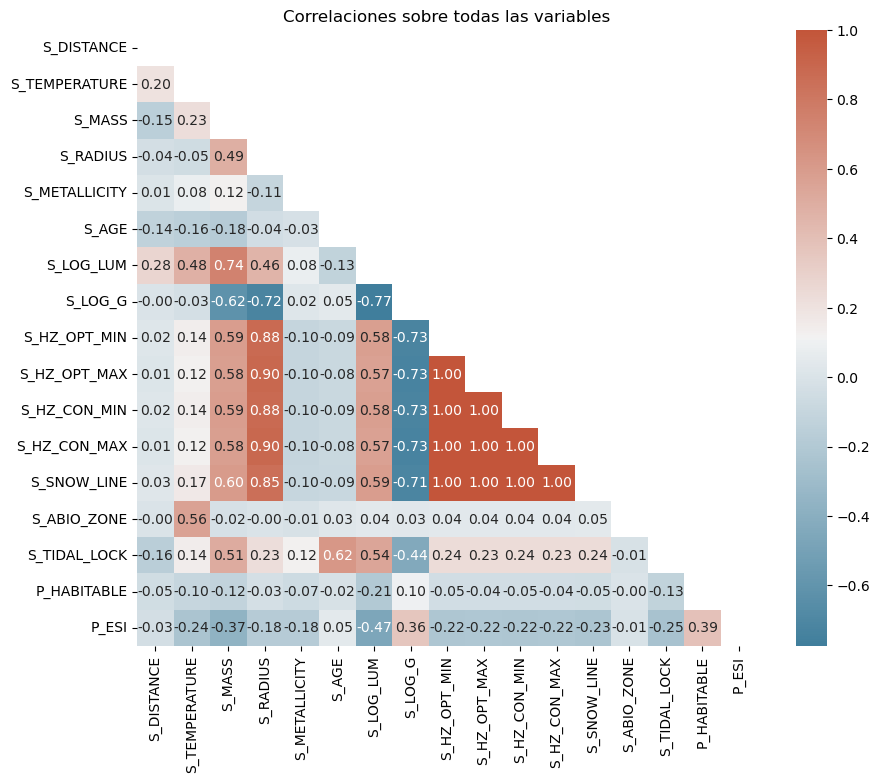

In [7]:
corrs=data[cols].corr() #correlaciones.
import seaborn as sns
f,a = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corrs,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs, mask=mask, ax=a, annot=True, fmt=".2f",cmap=cmap)
a.set(title="Correlaciones sobre todas las variables")
plt.show()

Para una visualización más limpia, seleccionamos las correlaciones sobre nuestras variables de interés.

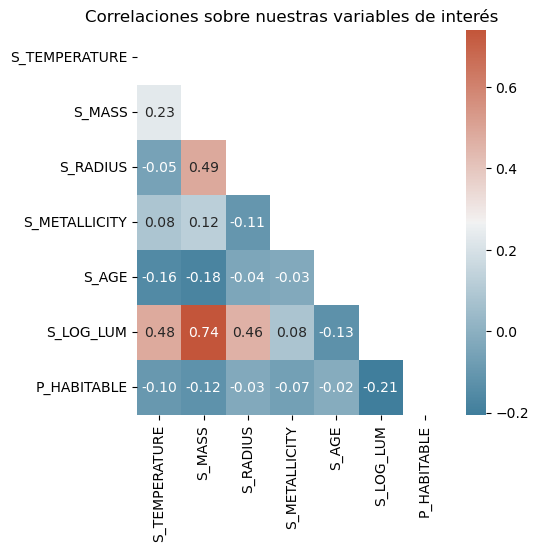

In [8]:
params2 = params + ["P_HABITABLE"]
corrs2=data[params2].corr()
f,a = plt.subplots(figsize=(5,5))
mask2 = np.triu(np.ones_like(corrs2,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs2, mask=mask2, ax=a, annot=True, fmt=".2f",cmap=cmap)
a.set(title="Correlaciones sobre nuestras variables de interés")
plt.show()

Se destaca que los valores de correlación con la *Habitabilidad*, en principio, son bajos.

#### 3.1.2. Análisis de planetas marcados como habitables.

En el conjunto de datos, los planetas con la variables P_HABITABLE de valores {1,2} son considerados habitables, por lo que los seleccionamos para su análisis.

In [9]:
data_habitable=data[data["P_HABITABLE"]>=1] # filtramos por aquellos exoplanetas considerados "habitables"

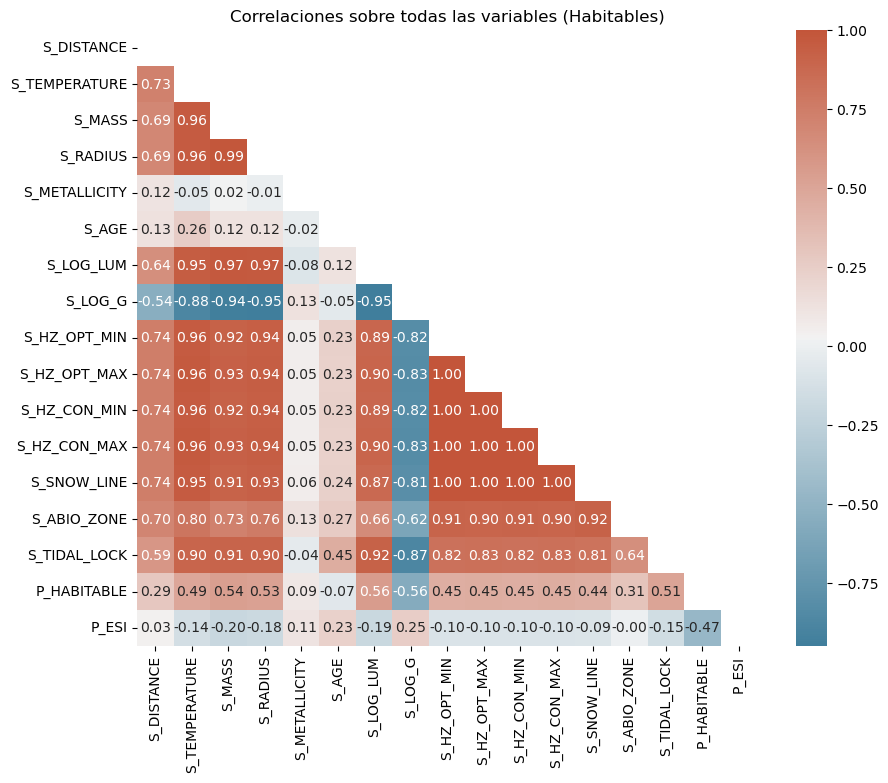

In [10]:
corrs_hab=data_habitable[cols].corr() #correlaciones.
fi,aa = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corrs_hab,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs_hab, mask=mask, ax=aa, annot=True, fmt=".2f",cmap=cmap)
aa.set(title="Correlaciones sobre todas las variables (Habitables)")
plt.show()

Nuevamente, seleccionamos las correlaciones sobre nuestras variables de interés.

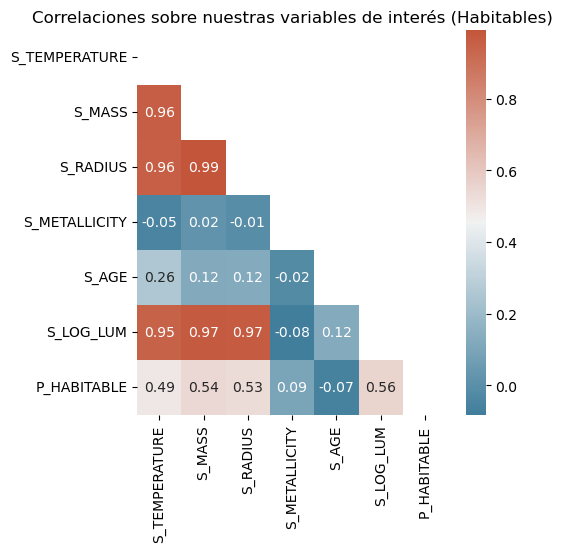

In [11]:
corrs2_hab=data_habitable[params2].corr() #correlaciones.
fi,aa = plt.subplots(figsize=(5,5))
mask = np.triu(np.ones_like(corrs2_hab,dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corrs2_hab, mask=mask, ax=aa, annot=True, fmt=".2f",cmap=cmap)
aa.set(title="Correlaciones sobre nuestras variables de interés (Habitables)")
plt.show()

Ahora que seleccionamos solo los planetas marcados como habitables, los valores de correlación son más notables para la variable P_HABITABLE. Además, superficialmente, es posible notar que los parámetros de *Edad* y *Metalicidad* no se relacionan con la *Habitabilidad*.

### 3.??? Exploración

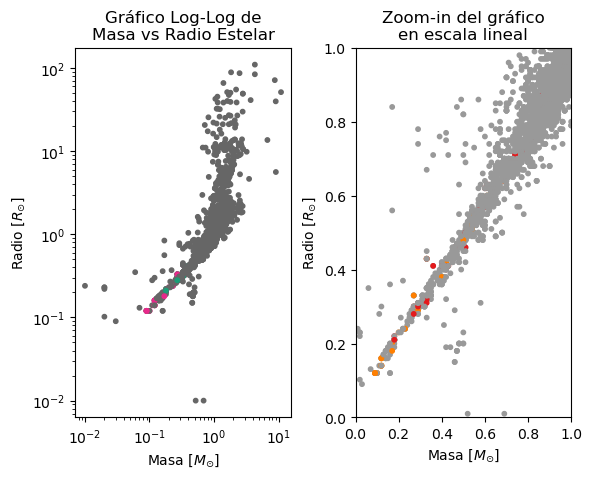

In [12]:
fig, ax = plt.subplots(1,2)
ax[0].scatter(data["S_MASS"],data["S_RADIUS"],c=data["P_HABITABLE"],s=10,cmap="Dark2_r")
ax[0].set(xlabel=r"Masa [$M_{\odot}$]",ylabel=r"Radio [$R_{\odot}$]",xscale="log",yscale="log",title="Gráfico Log-Log de\nMasa vs Radio Estelar")
ax[1].scatter(data["S_MASS"],data["S_RADIUS"],c=data["P_HABITABLE"],s=10,cmap="Set1_r")
ax[1].set(xlabel=r"Masa [$M_{\odot}$]",ylabel=r"Radio [$R_{\odot}$]", xlim=(0,1),ylim=(0,1), title="Zoom-in del gráfico\nen escala lineal")
fig.subplots_adjust(wspace=0.3)
plt.show()

In [13]:
fig,ax

(<Figure size 640x480 with 2 Axes>,
 array([<Axes: title={'center': 'Gráfico Log-Log de\nMasa vs Radio Estelar'}, xlabel='Masa [$M_{\\odot}$]', ylabel='Radio [$R_{\\odot}$]'>,
        <Axes: title={'center': 'Zoom-in del gráfico\nen escala lineal'}, xlabel='Masa [$M_{\\odot}$]', ylabel='Radio [$R_{\\odot}$]'>],
       dtype=object))

### 3.3 Análisis estadístico de las variables de interés.

Primero, creamos gráficos de caja para cada variable de interés, con el fin de entender como se distribuye el conjunto de datos. Luego, hacemos lo mismo con el conjunto de datos de planetas seleccionados como habitables, a fin de comparar.

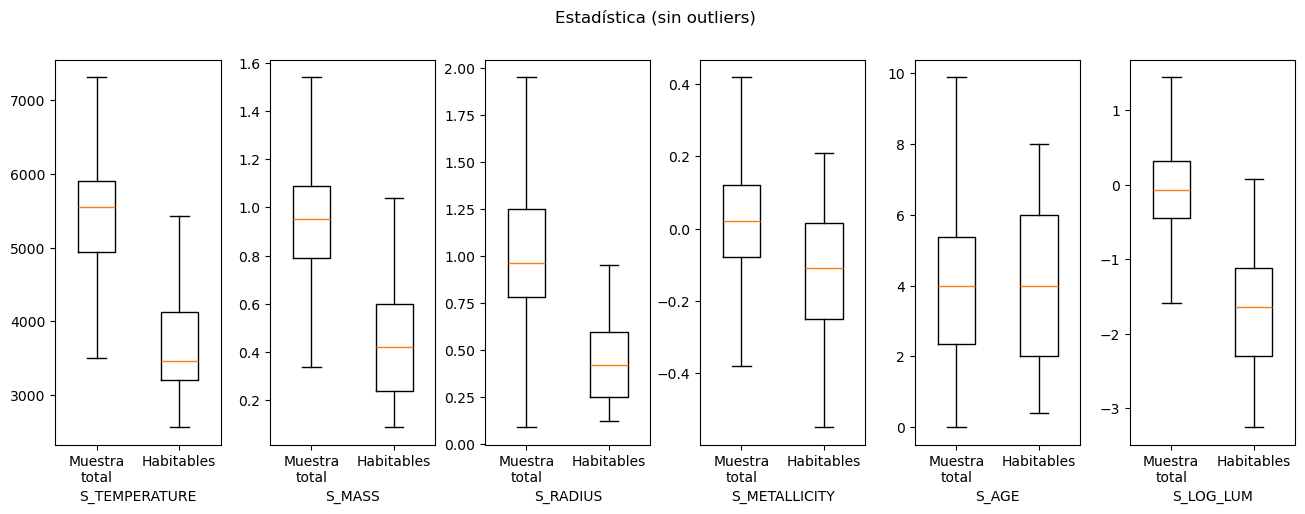

In [14]:
fig, axs =plt.subplots(1,len(params),figsize=(16,5)) # gráfico medio feo de estadística de nuestros parámetros más importantes
fig.suptitle("Estadística (sin outliers)")
for item, i in zip(params,range(len(params))):
    axs[i].boxplot([data[item].dropna(),data_habitable[item].dropna()],sym="",tick_labels=["Muestra\ntotal","Habitables"],widths=0.45) # sin NaN o queda en blanco
    axs[i].set(xlabel=item)
fig.subplots_adjust(wspace=0.3)
#fig.savefig("box.png", dpi=300) # descomentar para guardar la figura

Notamos que las estrellas anfitrionas de planetas habitables suelen tener valores cláramente más bajos de *Temperatura*, *Masa*, *Luminosidad* y *Radio*. La *metalicidad* parece ser solo un poco más baja, y la edad no aparenta un cambio destacable, más allá de una mayor dispersión.

## 4. Discusión e interpretación.

Resumen.

## 5. Mejores Candidatos.

Para elegir nuestros mejores candidatos de planetas habitables, seleccionamos aquellos cuyos parámetros sean más cercanos al valor de las medianas correspondientes a cada variable.

In [15]:
median=[]
for item in cols:
    median.append(data_habitable[item].median()) # calculamos la mediana de los datos numéricos
criteria=dict(zip(cols,median)) # se guardan en un diccionario con la llave el nombre de columna


In [16]:
near =np.ones(shape=(len(params),len(data_habitable))) # creamos un array para guardar las distancias a la mediana
for item, i in zip(params,range(len(params))):
     near[i,:]= np.abs(data_habitable[item]-criteria[item])
mean_dist=np.nanmean(near,axis=0) # promedio sin NaN, por objeto

arg=mean_dist.argsort() # ordenamos de más cercano a más lejano

In [17]:
candidates=data_habitable["P_NAME"].iloc[arg[0:3]] # nombres de los top 3 candidatos

In [18]:
selected=data_habitable.iloc[arg[0:3]] # tabla
selected

,P_NAME,S_TYPE,S_DISTANCE,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM,S_LOG_G,S_TYPE_TEMP,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABITABLE,P_ESI
626,GJ 3293 d,M2.5,20.19030,3466.0,0.42,0.40,0.02,NaN,-1.658,4.78,M,0.121306,0.315318,0.153651,0.298944,0.400280,0.028616,0.345489,2,0.629777
664,GJ 433 d,M2V,9.06456,3461.0,0.48,0.47,-0.17,NaN,-1.475,4.76,M,0.149764,0.389387,0.189698,0.369166,0.494156,0.029663,0.361214,2,0.742460
480,TOI-700 e,M2.5 V,31.12650,3459.0,0.42,0.42,-0.07,1.5,-1.640,4.81,M,0.123856,0.322058,0.156882,0.305334,0.408662,0.028274,0.286631,1,0.912032


In [19]:
# definimos un diccionario con estilos de gráfico para cada seleccionado, usando colores aptos para daltónicos
estilo = dict(zip(selected["P_NAME"],[("#d81b60","dashed"),("#1e88e5","dotted"),("#004d40","dashdot")]))

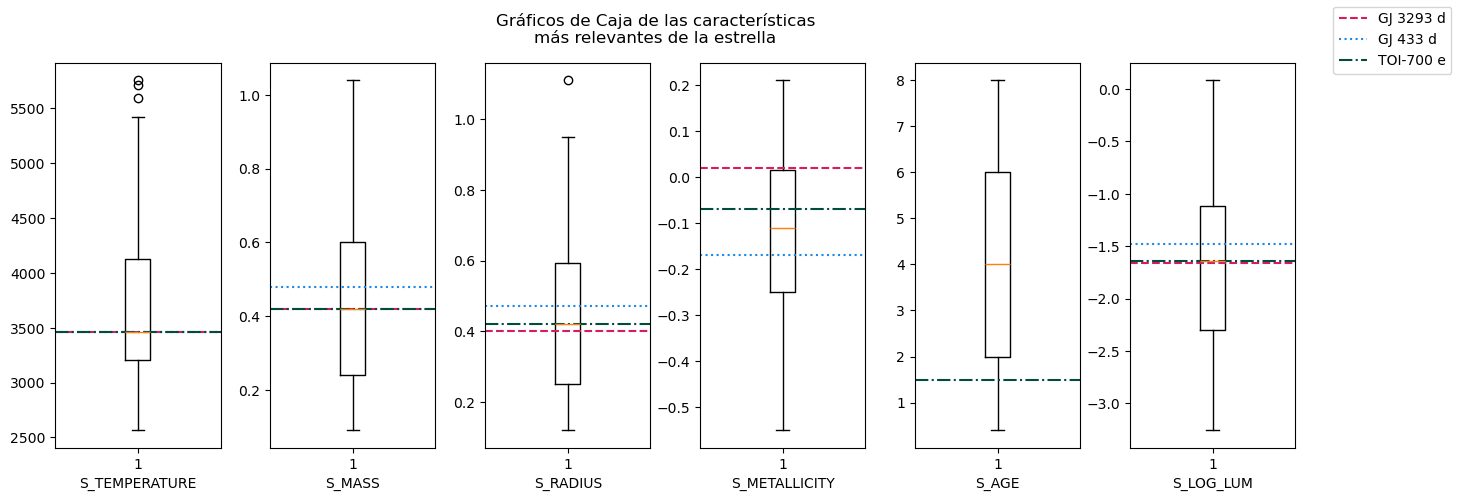

In [20]:
fig2, axs2 =plt.subplots(1,len(params),figsize=(16,5)) # gráfico de estadística de nuestros parámetros más importantes
for item, i in zip(params,range(len(params))): # iteramos en las características
    axs2[i].boxplot(data_habitable[item].dropna()) # sin NaN o queda en blanco
    for key,v in zip(estilo.keys(),range(3)): # iteramos en cada planeta
        if item == "S_MASS": # esto es para no tener 15 labels
            axs2[i].axhline(selected[item].iloc[v], ls=estilo[key][1], label=selected["P_NAME"].iloc[v], color=estilo[key][0])
        else:
            axs2[i].axhline(selected[item].iloc[v], ls=estilo[key][1], color=estilo[key][0])
    axs2[i].set(xlabel=item)
fig2.legend()
fig2.subplots_adjust(wspace=0.3) # añadimos espaciado entre los subplots para que se vea mejor
fig2.suptitle("Gráficos de Caja de las características\nmás relevantes de la estrella") # título
plt.show()
#fig.savefig("box.png", dpi=300) # descomentar para guardar la figura

Luego de ver los resultados, decidimos que es necesario sacar un promedio de las distancias ponderado

In [21]:
def weighted_mean(data,weights=np.ones_like(data)):
    return np.nansum(data*weights)/np.sum(weights)
wei_mean_dist=np.apply_along_axis(weighted_mean,0,near,weights=np.array([0.5,0.1,0.5,0.1,0.5,1]))
args=wei_mean_dist.argsort() # ordenamos de más cercano a más lejano

In [22]:
selected_wei=data_habitable.iloc[args[0:3]] # tabla
selected_wei

,P_NAME,S_TYPE,S_DISTANCE,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM,S_LOG_G,S_TYPE_TEMP,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABITABLE,P_ESI
626,GJ 3293 d,M2.5,20.19030,3466.0,0.42,0.40,0.02,NaN,-1.658,4.78,M,0.121306,0.315318,0.153651,0.298944,0.400280,0.028616,0.345489,2,0.629777
664,GJ 433 d,M2V,9.06456,3461.0,0.48,0.47,-0.17,NaN,-1.475,4.76,M,0.149764,0.389387,0.189698,0.369166,0.494156,0.029663,0.361214,2,0.742460
2178,K2-18 b,M2.5 V,38.02660,3457.0,0.36,0.41,0.12,NaN,-1.597,4.79,M,0.130145,0.338444,0.164848,0.320869,0.429402,0.026766,0.328185,2,0.700938


In [23]:
s_type = data_habitable["S_TYPE"].dropna().apply(lambda a: a[0]) # limpieza básica de los strings para categorizar por tipo espectral
types,counts=np.unique(s_type,return_counts=True)

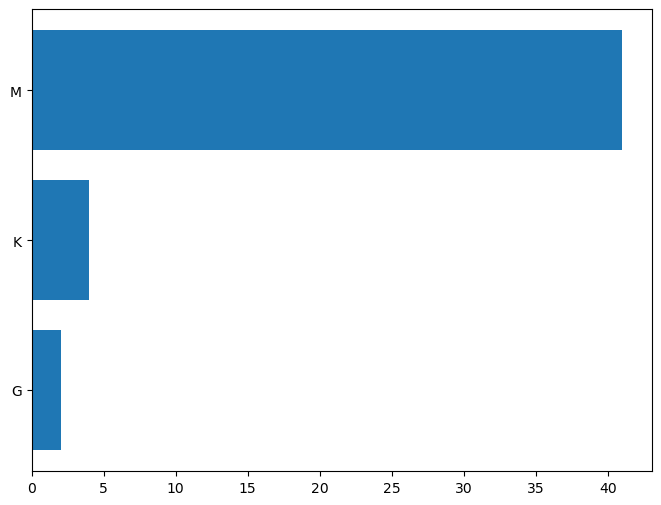

In [24]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.add_subplot()
ax1.barh(types,counts,)
plt.show()

## Resultados

## Conclusiones